# Kaleb Alejandro Aguilar Ávila
## Procesamiento de Lenguaje Natural
## Práctica 3: Bolsas de Terminos y Esquemas de Pesado

In [2]:
import os
import re
from tensorflow.keras.preprocessing.text import Tokenizer


In [3]:
def get_texts_from_file(path_corpus, path_truth):
    tr_txt = []
    tr_y = []

    
    with open(path_corpus, "r") as f_corpus, open(path_truth, "r") as f_truth:
        for twitt in f_corpus:
            tr_txt.append(twitt)
        for label in f_truth:
            tr_y.append(label)
    
    return tr_txt, tr_y

In [4]:
tr_txt,tr_y = get_texts_from_file("./mex20_train.txt","./mex20_train_labels.txt")

 # Estadísticas Simples

Counter({'0\n': 3759, '1\n': 1519})


Text(0, 0.5, 'Class')

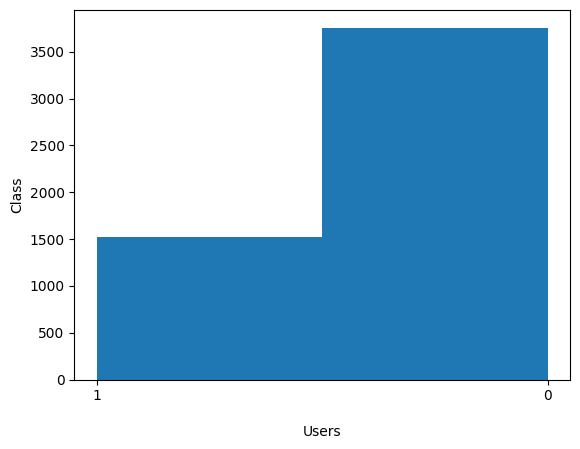

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
%matplotlib inline

print(Counter(tr_y))

plt.hist(tr_y, bins= len(set(tr_y)))

plt.xlabel('Users')
plt.ylabel('Class')

 # Un ojo a los datos

In [6]:
tr_txt[:10]

['@USUARIO @USUARIO @USUARIO Q se puede esperar del maricon de closet de la Yañez aun recuerdo esa ves q lo vi en zona rosa viendo quien lo levantada\n',
 '@USUARIO La piel nueva siempre arde un poquito los primeros días... y más con este puto clima\n',
 'Ustedes no se enamoran de mí… por tontas.\n',
 'Me las va a pagar esa puta gorda roba tuits...\n',
 '@USUARIO LA GENTE ES TONTA PORQUE NO SE DAN CUENTA QUE TÚ HACES A BATMAN AZUL\n',
 'Estoy muy encabronada con las pseudo feministas por tontas e iletradas, a veces me avergüenza ser mujer; preferiría tener un falo. #NiUnaMas\n',
 'Anden putos, recuerdan el #noerapenal #Holanda fuera de #Rusia2018, esto se llama #karma ehhhhhhhh #puuuuuutos\n',
 'Si no tienen chichis no traten de enseñar se ven muy mal y más cuando son prietas.\n',
 'Ojalá asi me agarrars cuando te digo que me voy en lugar de correrme a la verga cada 5 minutos.\n',
 '@USUARIO @USUARIO @USUARIO @USUARIO Es solo un HDP aprovechado y que su "Diosito Bimbo" me perdone\n']

 # Construccion Simple del Vocabulario

In [7]:
import nltk
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()
corpus_palabras = []
for doc in tr_txt:
    corpus_palabras += tokenizer.tokenize(doc)

fdist = nltk.FreqDist(corpus_palabras)

In [8]:
fdist

FreqDist({',': 3016, 'de': 2915, 'que': 2829, '.': 2604, 'la': 2031, 'a': 1956, 'y': 1856, '!': 1435, 'no': 1430, '@USUARIO': 1399, ...})

In [9]:
len(fdist)

15194

In [10]:
def sortFreqDist(freqdict):
    aux = [(freqdict[key],key) for key in freqdict]
    aux.sort()
    aux.reverse()
    return aux

In [11]:
V = sortFreqDist(fdist)
V = V[:5000]

In [12]:
dict_indices = dict()
cont = 0
for weight,word in V:
    dict_indices[word] = cont
    cont += 1

 # Bolsa de Términos

In [30]:
import numpy as np

def build_bow_tr(tr_txt,V,dict_indices):
    BOW = np.zeros((len(tr_txt),len(V)),dtype=int)

    cont_doc = 0
    for tr in tr_txt:
        fdist_doc = nltk.FreqDist(tokenizer.tokenize(tr))

        for word in fdist_doc:
            if word in dict_indices:
                BOW[cont_doc,dict_indices[word]] = 1
        cont_doc += 1
    
    return BOW

In [43]:
BOW_tr = build_bow_tr(tr_txt,V,dict_indices)

In [44]:
BOW_tr.shape

(5278, 5000)

 # Bolsa de Términos de Validación

Counter({'0\n': 418, '1\n': 169})


Text(0, 0.5, 'Class')

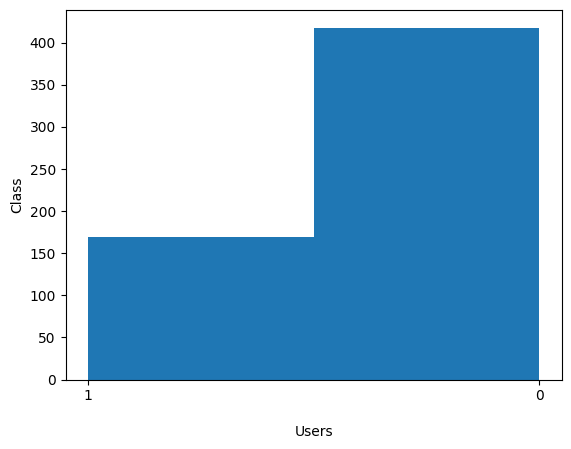

In [34]:
val_txt,val_y = get_texts_from_file("./mex20_val.txt","./mex20_val_labels.txt")

print(Counter(val_y))

plt.hist(val_y, bins= len(set(val_y)))

plt.xlabel('Users')
plt.ylabel('Class')


In [35]:
BOW_val = BOW = build_bow_tr(val_txt,V,dict_indices)

 # Clasificación

In [39]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics  import accuracy_score, confusion_matrix,f1_score,precision_recall_fscore_support, roc_auc_score

In [40]:
tr_y = list(map(int, tr_y))
val_y = list(map(int, val_y))

In [45]:
parameters = {'C': [.05,.12,.25,.5,1,2,4]}
svr = svm.LinearSVC(class_weight = 'balanced')
grid = GridSearchCV(estimator=svr,param_grid=parameters,n_jobs=8,scoring='f1_macro',cv=5)

grid.fit(BOW_tr,tr_y)
y_pred = grid.predict(BOW_val)

/Users/kalebaguilar/miniforge3/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/kalebaguilar/miniforge3/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/kalebaguilar/miniforge3/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/kalebaguilar/miniforge3/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/kalebaguilar/miniforge3/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/kalebaguilar/miniforge3/lib/python3.12/site-pack

In [47]:
p,r,f,_ = precision_recall_fscore_support(val_y,y_pred,average='macro',pos_label=1)

print(confusion_matrix(val_y,y_pred))
print(metrics.classification_report(val_y,y_pred))

[[356  62]
 [ 49 120]]
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       418
           1       0.66      0.71      0.68       169

    accuracy                           0.81       587
   macro avg       0.77      0.78      0.77       587
weighted avg       0.82      0.81      0.81       587



In [48]:
incorrect = []
for e in zip(val_y,y_pred,range(len(val_y))):
    if e[0] != e[1]:
        incorrect += [e[2]]

In [50]:
for e in incorrect:
    case = e
    if 'madre' in val_txt[case].strip():
        print("Texto: ",val_txt[case].strip())
        print("Truth: ", val_y[case])
        print("Pred : ",y_pred[case])

Texto:  Al perro que se te acerque le parto su madre a si de facil
Truth:  1
Pred :  0
Texto:  @USUARIO Ya m tienen hasta la madre esos maes
Truth:  0
Pred :  1
Texto:  Amigos, Vero tiene toda la razón por eso no hay que ir a esa madre, mejor todos a Costeño a empedar.
Truth:  0
Pred :  1
Texto:  Pero un día te voy a tapar el culo mientras te estoy lamiendo la pantunfla a ver si te da una embolia, hija de tu puta madre
Truth:  1
Pred :  0
Texto:  @USUARIO PA tener 80 estas a toda madre!
Truth:  0
Pred :  1
Texto:  Por está madre me agarré a vergazos con el de la combi y no le pagué, el puto decía que ya no valen.
Truth:  1
Pred :  0
Texto:  Ya van a ser las putas 8 y la pasarela no tiene para cuando empezar perra madre
Truth:  0
Pred :  1
Texto:  Políticos pseudoaficiomados que sólo en finales hablan de beisbol pueden ir mucho a chingar a su madre. Y peor cuando opinan.
Truth:  1
Pred :  0
Texto:  @USUARIO @USUARIO Hija de tu madre 😂😂😂😂🖕🏼🖕🏼🤚🏻
Truth:  0
Pred :  1
Texto:  La anciana madr